**Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df1 = pd.read_table('/content/drive/MyDrive/Recsys_data/movies.dat', header=None, delimiter='::')
df2 = pd.read_table('/content/drive/MyDrive/Recsys_data/ratings.dat', header=None, delimiter='::')
df3 = pd.read_table('/content/drive/MyDrive/Recsys_data/users.dat', header=None, delimiter='::')

<ipython-input-5-717d5a1c2416>:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df1 = pd.read_table('/content/drive/MyDrive/Recsys_data/movies.dat', header=None, delimiter='::')
<ipython-input-5-717d5a1c2416>:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df2 = pd.read_table('/content/drive/MyDrive/Recsys_data/ratings.dat', header=None, delimiter='::')
<ipython-input-5-717d5a1c2416>:3: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifyi

In [6]:
df1

,0,1,2
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
3878,3948,Meet the Parents (2000),Comedy
3879,3949,Requiem for a Dream (2000),Drama
3880,3950,Tigerland (2000),Drama
3881,3951,Two Family House (2000),Drama


In [7]:
df1.rename(columns = {0:'MovieID',
                         1:'Title',
                         2:'Genres'},
              inplace = True)

In [8]:
df2

,0,1,2,3
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291
...,...,...,...,...
1000204,6040,1091,1,956716541
1000205,6040,1094,5,956704887
1000206,6040,562,5,956704746
1000207,6040,1096,4,956715648


In [9]:
df2.rename(columns = {0:'UserID',
                         1:'MovieID',
                         2:'Rating',
                      3:'Timestamp'},
              inplace = True)

In [10]:
df1

,MovieID,Title,Genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
3878,3948,Meet the Parents (2000),Comedy
3879,3949,Requiem for a Dream (2000),Drama
3880,3950,Tigerland (2000),Drama
3881,3951,Two Family House (2000),Drama


In [11]:
df2

,UserID,MovieID,Rating,Timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291
...,...,...,...,...
1000204,6040,1091,1,956716541
1000205,6040,1094,5,956704887
1000206,6040,562,5,956704746
1000207,6040,1096,4,956715648


In [12]:
df3.rename(columns = {0:'UserID',
                         1:'Gender',
                         2:'Age',
                      3:'Occupation',
                      4:'Zip-code'},
              inplace = True)

In [13]:
df3

,UserID,Gender,Age,Occupation,Zip-code
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455
...,...,...,...,...,...
6035,6036,F,25,15,32603
6036,6037,F,45,1,76006
6037,6038,F,56,1,14706
6038,6039,F,45,0,01060


In [14]:
movie_ratings = df2.merge(df1, on='MovieID')
movie_ratings['Title'].value_counts()[0:10]

American Beauty (1999)                                   3428
Star Wars: Episode IV - A New Hope (1977)                2991
Star Wars: Episode V - The Empire Strikes Back (1980)    2990
Star Wars: Episode VI - Return of the Jedi (1983)        2883
Jurassic Park (1993)                                     2672
Saving Private Ryan (1998)                               2653
Terminator 2: Judgment Day (1991)                        2649
Matrix, The (1999)                                       2590
Back to the Future (1985)                                2583
Silence of the Lambs, The (1991)                         2578
Name: Title, dtype: int64

In [15]:
df = pd.merge(df1,df2,how="outer",on="MovieID")

In [16]:
df.head()

,MovieID,Title,Genres,UserID,Rating,Timestamp
0,1,Toy Story (1995),Animation|Children's|Comedy,1.0,5.0,978824268.0
1,1,Toy Story (1995),Animation|Children's|Comedy,6.0,4.0,978237008.0
2,1,Toy Story (1995),Animation|Children's|Comedy,8.0,4.0,978233496.0
3,1,Toy Story (1995),Animation|Children's|Comedy,9.0,5.0,978225952.0
4,1,Toy Story (1995),Animation|Children's|Comedy,10.0,5.0,978226474.0


In [17]:
df = pd.merge(df3,df,how="outer",on="UserID")

In [18]:
df

,UserID,Gender,Age,Occupation,Zip-code,MovieID,Title,Genres,Rating,Timestamp
0,1.0,F,1.0,10.0,48067,1,Toy Story (1995),Animation|Children's|Comedy,5.0,978824268.0
1,1.0,F,1.0,10.0,48067,48,Pocahontas (1995),Animation|Children's|Musical|Romance,5.0,978824351.0
2,1.0,F,1.0,10.0,48067,150,Apollo 13 (1995),Drama,5.0,978301777.0
3,1.0,F,1.0,10.0,48067,260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Fantasy|Sci-Fi,4.0,978300760.0
4,1.0,F,1.0,10.0,48067,527,Schindler's List (1993),Drama|War,5.0,978824195.0
...,...,...,...,...,...,...,...,...,...,...
1000381,NaN,NaN,NaN,NaN,NaN,3650,Anguish (Angustia) (1986),Horror,NaN,NaN
1000382,NaN,NaN,NaN,NaN,NaN,3750,Boricua's Bond (2000),Drama,NaN,NaN
1000383,NaN,NaN,NaN,NaN,NaN,3829,Mad About Mambo (2000),Comedy|Romance,NaN,NaN
1000384,NaN,NaN,NaN,NaN,NaN,3856,Autumn Heart (1999),Drama,NaN,NaN


In [19]:
df.isna().sum()

UserID        177
Gender        177
Age           177
Occupation    177
Zip-code      177
MovieID         0
Title           0
Genres          0
Rating        177
Timestamp     177
dtype: int64

In [20]:
df.dropna(inplace=True)

In [21]:
df.isna().sum()

UserID        0
Gender        0
Age           0
Occupation    0
Zip-code      0
MovieID       0
Title         0
Genres        0
Rating        0
Timestamp     0
dtype: int64

In [22]:
df

,UserID,Gender,Age,Occupation,Zip-code,MovieID,Title,Genres,Rating,Timestamp
0,1.0,F,1.0,10.0,48067,1,Toy Story (1995),Animation|Children's|Comedy,5.0,978824268.0
1,1.0,F,1.0,10.0,48067,48,Pocahontas (1995),Animation|Children's|Musical|Romance,5.0,978824351.0
2,1.0,F,1.0,10.0,48067,150,Apollo 13 (1995),Drama,5.0,978301777.0
3,1.0,F,1.0,10.0,48067,260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Fantasy|Sci-Fi,4.0,978300760.0
4,1.0,F,1.0,10.0,48067,527,Schindler's List (1993),Drama|War,5.0,978824195.0
...,...,...,...,...,...,...,...,...,...,...
1000204,6040.0,M,25.0,6.0,11106,3683,Blood Simple (1984),Drama|Film-Noir,4.0,960971696.0
1000205,6040.0,M,25.0,6.0,11106,3703,Mad Max 2 (a.k.a. The Road Warrior) (1981),Action|Sci-Fi,4.0,964828575.0
1000206,6040.0,M,25.0,6.0,11106,3735,Serpico (1973),Crime|Drama,4.0,960971654.0
1000207,6040.0,M,25.0,6.0,11106,3751,Chicken Run (2000),Animation|Children's|Comedy,4.0,964828782.0


In [23]:
df['Genres'] = df['Genres'].apply(lambda x: x.split('|'))

In [24]:
df

,UserID,Gender,Age,Occupation,Zip-code,MovieID,Title,Genres,Rating,Timestamp
0,1.0,F,1.0,10.0,48067,1,Toy Story (1995),"[Animation, Children's, Comedy]",5.0,978824268.0
1,1.0,F,1.0,10.0,48067,48,Pocahontas (1995),"[Animation, Children's, Musical, Romance]",5.0,978824351.0
2,1.0,F,1.0,10.0,48067,150,Apollo 13 (1995),[Drama],5.0,978301777.0
3,1.0,F,1.0,10.0,48067,260,Star Wars: Episode IV - A New Hope (1977),"[Action, Adventure, Fantasy, Sci-Fi]",4.0,978300760.0
4,1.0,F,1.0,10.0,48067,527,Schindler's List (1993),"[Drama, War]",5.0,978824195.0
...,...,...,...,...,...,...,...,...,...,...
1000204,6040.0,M,25.0,6.0,11106,3683,Blood Simple (1984),"[Drama, Film-Noir]",4.0,960971696.0
1000205,6040.0,M,25.0,6.0,11106,3703,Mad Max 2 (a.k.a. The Road Warrior) (1981),"[Action, Sci-Fi]",4.0,964828575.0
1000206,6040.0,M,25.0,6.0,11106,3735,Serpico (1973),"[Crime, Drama]",4.0,960971654.0
1000207,6040.0,M,25.0,6.0,11106,3751,Chicken Run (2000),"[Animation, Children's, Comedy]",4.0,964828782.0


In [25]:
all_genres = set(genre for sublist in df['Genres'] for genre in sublist)

In [26]:
for genre in all_genres:
    df[f'{genre}'] = df['Genres'].apply(lambda x: 1 if genre in x else 0)
df = df.drop(columns=['Genres'])

In [27]:
df

,UserID,Gender,Age,Occupation,Zip-code,MovieID,Title,Rating,Timestamp,Comedy,...,Sci-Fi,Romance,Drama,War,Horror,Film-Noir,Children's,Western,Fantasy,Crime
0,1.0,F,1.0,10.0,48067,1,Toy Story (1995),5.0,978824268.0,1,...,0,0,0,0,0,0,1,0,0,0
1,1.0,F,1.0,10.0,48067,48,Pocahontas (1995),5.0,978824351.0,0,...,0,1,0,0,0,0,1,0,0,0
2,1.0,F,1.0,10.0,48067,150,Apollo 13 (1995),5.0,978301777.0,0,...,0,0,1,0,0,0,0,0,0,0
3,1.0,F,1.0,10.0,48067,260,Star Wars: Episode IV - A New Hope (1977),4.0,978300760.0,0,...,1,0,0,0,0,0,0,0,1,0
4,1.0,F,1.0,10.0,48067,527,Schindler's List (1993),5.0,978824195.0,0,...,0,0,1,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1000204,6040.0,M,25.0,6.0,11106,3683,Blood Simple (1984),4.0,960971696.0,0,...,0,0,1,0,0,1,0,0,0,0
1000205,6040.0,M,25.0,6.0,11106,3703,Mad Max 2 (a.k.a. The Road Warrior) (1981),4.0,964828575.0,0,...,1,0,0,0,0,0,0,0,0,0
1000206,6040.0,M,25.0,6.0,11106,3735,Serpico (1973),4.0,960971654.0,0,...,0,0,1,0,0,0,0,0,0,1
1000207,6040.0,M,25.0,6.0,11106,3751,Chicken Run (2000),4.0,964828782.0,1,...,0,0,0,0,0,0,1,0,0,0


EDA

In [28]:
ratings_cnt = len(df['Rating'])
movies_cnt = df['MovieID'].nunique()
users_cnt = df['UserID'].nunique()

In [29]:
ratings_cnt

1000209

In [30]:
print(movies_cnt)
print(users_cnt)

3706
6040


<ipython-input-31-61d133866be9>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Rating',data=df,palette="viridis")


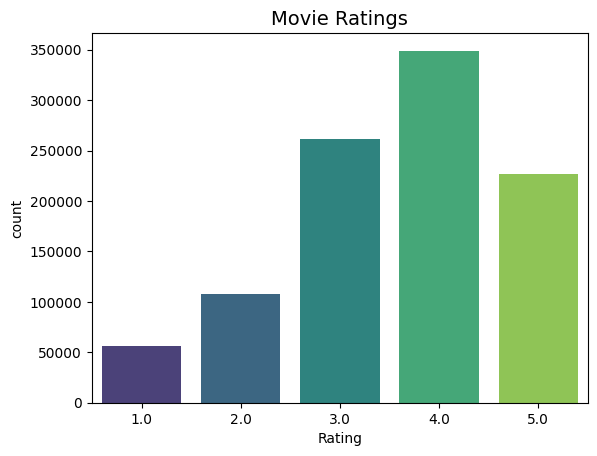

In [31]:
sns.countplot(x='Rating',data=df,palette="viridis")
plt.title('Movie Ratings', fontsize = 14)
plt.show()

Non uniform distribution

In [32]:
print(f"Mean rating: {round(df['Rating'].mean(),2)}.")

Mean rating: 3.58.


In [33]:
mean_ratings = df.groupby('UserID')['Rating'].mean()
print(f"Mean rating per user: {round(mean_ratings.mean(),2)}.")

Mean rating per user: 3.7.


Text(0, 0.5, 'Frequency')

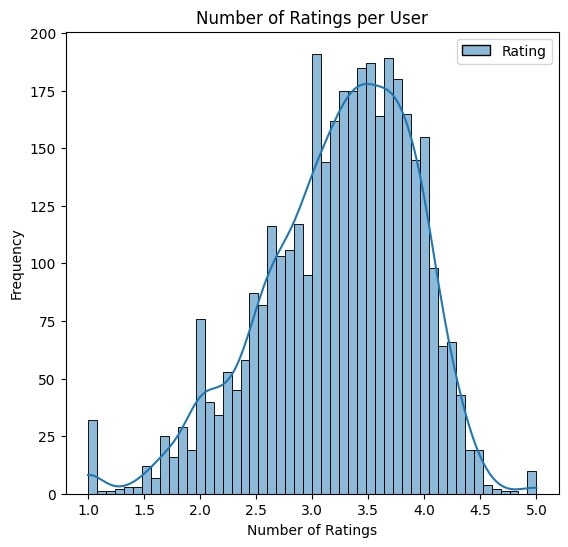

In [108]:
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.histplot(mean_ratings, bins=50, kde=True, color='salmon')
plt.title("Number of Ratings per User")
plt.xlabel("Number of Ratings")
plt.ylabel("Frequency")

In [34]:
movie_ratings = df2.merge(df1, on='MovieID')
movie_ratings['Title'].value_counts()[0:10]

American Beauty (1999)                                   3428
Star Wars: Episode IV - A New Hope (1977)                2991
Star Wars: Episode V - The Empire Strikes Back (1980)    2990
Star Wars: Episode VI - Return of the Jedi (1983)        2883
Jurassic Park (1993)                                     2672
Saving Private Ryan (1998)                               2653
Terminator 2: Judgment Day (1991)                        2649
Matrix, The (1999)                                       2590
Back to the Future (1985)                                2583
Silence of the Lambs, The (1991)                         2578
Name: Title, dtype: int64

In [35]:
mean_ratings = df2.groupby('MovieID')[['Rating']].mean()
lowest_rated = mean_ratings['Rating'].idxmin()
df1[df1['MovieID']==lowest_rated]

,MovieID,Title,Genres
125,127,"Silence of the Palace, The (Saimt el Qusur) (1...",Drama


Recommendation

In [36]:
highest_rated = mean_ratings['Rating'].idxmax()
df1[df1['MovieID'] == highest_rated]



,MovieID,Title,Genres
777,787,"Gate of Heavenly Peace, The (1995)",Documentary


In [37]:
df2[df2['MovieID']==highest_rated]

,UserID,MovieID,Rating,Timestamp
19836,149,787,5,977325719
458840,2825,787,5,972610193
465525,2872,787,5,972423586


In [38]:
df.head()

,UserID,Gender,Age,Occupation,Zip-code,MovieID,Title,Rating,Timestamp,Comedy,...,Sci-Fi,Romance,Drama,War,Horror,Film-Noir,Children's,Western,Fantasy,Crime
0,1.0,F,1.0,10.0,48067,1,Toy Story (1995),5.0,978824268.0,1,...,0,0,0,0,0,0,1,0,0,0
1,1.0,F,1.0,10.0,48067,48,Pocahontas (1995),5.0,978824351.0,0,...,0,1,0,0,0,0,1,0,0,0
2,1.0,F,1.0,10.0,48067,150,Apollo 13 (1995),5.0,978301777.0,0,...,0,0,1,0,0,0,0,0,0,0
3,1.0,F,1.0,10.0,48067,260,Star Wars: Episode IV - A New Hope (1977),4.0,978300760.0,0,...,1,0,0,0,0,0,0,0,1,0
4,1.0,F,1.0,10.0,48067,527,Schindler's List (1993),5.0,978824195.0,0,...,0,0,1,1,0,0,0,0,0,0


In [39]:
df.columns

Index(['UserID', 'Gender', 'Age', 'Occupation', 'Zip-code', 'MovieID', 'Title',
       'Rating', 'Timestamp', 'Comedy', 'Thriller', 'Animation', 'Musical',
       'Mystery', 'Action', 'Adventure', 'Documentary', 'Sci-Fi', 'Romance',
       'Drama', 'War', 'Horror', 'Film-Noir', 'Children's', 'Western',
       'Fantasy', 'Crime'],
      dtype='object')

In [40]:
df['Gender'] = df['Gender'].replace({'M': 1, 'F': 0})

In [41]:
df.head()

,UserID,Gender,Age,Occupation,Zip-code,MovieID,Title,Rating,Timestamp,Comedy,...,Sci-Fi,Romance,Drama,War,Horror,Film-Noir,Children's,Western,Fantasy,Crime
0,1.0,0,1.0,10.0,48067,1,Toy Story (1995),5.0,978824268.0,1,...,0,0,0,0,0,0,1,0,0,0
1,1.0,0,1.0,10.0,48067,48,Pocahontas (1995),5.0,978824351.0,0,...,0,1,0,0,0,0,1,0,0,0
2,1.0,0,1.0,10.0,48067,150,Apollo 13 (1995),5.0,978301777.0,0,...,0,0,1,0,0,0,0,0,0,0
3,1.0,0,1.0,10.0,48067,260,Star Wars: Episode IV - A New Hope (1977),4.0,978300760.0,0,...,1,0,0,0,0,0,0,0,1,0
4,1.0,0,1.0,10.0,48067,527,Schindler's List (1993),5.0,978824195.0,0,...,0,0,1,1,0,0,0,0,0,0


In [42]:
movie_stats = df2.groupby('MovieID')['Rating'].agg(['count', 'mean'])
movie_stats.head()

,count,mean
MovieID,,
1,2077,4.146846
2,701,3.201141
3,478,3.016736
4,170,2.729412
5,296,3.006757


In [43]:
C = movie_stats['count'].mean()
m = movie_stats['mean'].mean()

print(f"Average number of ratings for a given movie: {C:.2f}")
print(f"Average rating for a given movie: {m:.2f}")

def bayesian_avg(ratings):
    bayesian_avg = (C*m+ratings.sum())/(C+ratings.count())
    return round(bayesian_avg, 3)

Average number of ratings for a given movie: 269.89
Average rating for a given movie: 3.24


In [44]:
gateofheavenly = pd.Series([5, 5])
bayesian_avg(gateofheavenly)

3.252

In [45]:
bayesian_avg_ratings = df2.groupby('MovieID')['Rating'].agg(bayesian_avg).reset_index()
bayesian_avg_ratings.columns = ['MovieID', 'bayesian_avg']
movie_stats = movie_stats.merge(bayesian_avg_ratings, on='MovieID')

In [46]:
movie_stats = movie_stats.merge(df1[['MovieID', 'Title']])
movie_stats.sort_values('bayesian_avg', ascending=False).head()

,MovieID,count,mean,bayesian_avg,Title
309,318,2227,4.554558,4.412,"Shawshank Redemption, The (1994)"
802,858,2223,4.524966,4.386,"Godfather, The (1972)"
513,527,2304,4.510417,4.377,Schindler's List (1993)
1108,1198,2514,4.477725,4.358,Raiders of the Lost Ark (1981)
253,260,2991,4.453694,4.353,Star Wars: Episode IV - A New Hope (1977)


In [47]:
movie_stats.sort_values('bayesian_avg', ascending=True).head()


,MovieID,count,mean,bayesian_avg,Title
3353,3593,342,1.611111,2.329,Battlefield Earth (2000)
2496,2701,902,2.158537,2.407,Wild Wild West (1999)
1432,1556,367,1.871935,2.451,Speed 2: Cruise Control (1997)
532,546,350,1.874286,2.468,Super Mario Bros. (1993)
2441,2643,332,1.888554,2.494,Superman IV: The Quest for Peace (1987)


In [48]:
df1['Genres'] = df1['Genres'].apply(lambda x: x.split("|"))
df1.head()

,MovieID,Title,Genres
0,1,Toy Story (1995),"[Animation, Children's, Comedy]"
1,2,Jumanji (1995),"[Adventure, Children's, Fantasy]"
2,3,Grumpier Old Men (1995),"[Comedy, Romance]"
3,4,Waiting to Exhale (1995),"[Comedy, Drama]"
4,5,Father of the Bride Part II (1995),[Comedy]


In [49]:
from collections import Counter

genre_frequency = Counter(g for genres in df1['Genres'] for g in genres)

print(f"There are {len(genre_frequency)} genres.")

genre_frequency

There are 18 genres.


Counter({'Animation': 105,
         "Children's": 251,
         'Comedy': 1200,
         'Adventure': 283,
         'Fantasy': 68,
         'Romance': 471,
         'Drama': 1603,
         'Action': 503,
         'Crime': 211,
         'Thriller': 492,
         'Horror': 343,
         'Sci-Fi': 276,
         'Documentary': 127,
         'War': 143,
         'Musical': 114,
         'Mystery': 106,
         'Film-Noir': 44,
         'Western': 68})

In [50]:
print("The 5 most common genres: \n", genre_frequency.most_common(5))

The 5 most common genres: 
 [('Drama', 1603), ('Comedy', 1200), ('Action', 503), ('Thriller', 492), ('Romance', 471)]


<ipython-input-51-0ac3a96c2e54>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Genre', y='count', data=genre_frequency_df.sort_values(by='count', ascending=False), palette=color_palette)


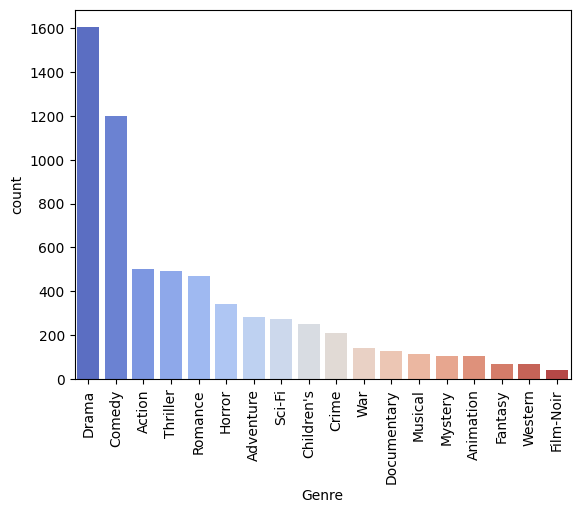

In [51]:
genre_frequency_df = pd.DataFrame([genre_frequency]).T.reset_index()
genre_frequency_df.columns = ['Genre', 'count']

# Define a color palette
color_palette = sns.color_palette("coolwarm", len(genre_frequency_df))

# Create the bar plot with color palette
sns.barplot(x='Genre', y='count', data=genre_frequency_df.sort_values(by='count', ascending=False), palette=color_palette)
plt.xticks(rotation=90)
plt.show()


In [52]:
from scipy.sparse import csr_matrix

def create_X(df):
    """
    Generates a sparse matrix from ratings dataframe.

    Args:
        df: pandas dataframe containing 3 columns (userId, movieId, rating)

    Returns:
        X: sparse matrix
        user_mapper: dict that maps user id's to user indices
        user_inv_mapper: dict that maps user indices to user id's
        movie_mapper: dict that maps movie id's to movie indices
        movie_inv_mapper: dict that maps movie indices to movie id's
    """
    M = df['UserID'].nunique()
    N = df['MovieID'].nunique()

    user_mapper = dict(zip(np.unique(df["UserID"]), list(range(M))))
    movie_mapper = dict(zip(np.unique(df["MovieID"]), list(range(N))))

    user_inv_mapper = dict(zip(list(range(M)), np.unique(df["UserID"])))
    movie_inv_mapper = dict(zip(list(range(N)), np.unique(df["MovieID"])))

    user_index = [user_mapper[i] for i in df['UserID']]
    item_index = [movie_mapper[i] for i in df['MovieID']]

    X = csr_matrix((df["Rating"], (user_index,item_index)), shape=(M,N))

    return X, user_mapper, movie_mapper, user_inv_mapper, movie_inv_mapper

X, user_mapper, movie_mapper, user_inv_mapper, movie_inv_mapper = create_X(df2)

In [53]:
X.shape

(6040, 3706)

In [54]:
n_total = X.shape[0]*X.shape[1]
n_ratings = X.nnz
sparsity = n_ratings/n_total
print(f"Matrix sparsity: {round(sparsity*100,2)}%")

Matrix sparsity: 4.47%


In [55]:
n_ratings_per_user = X.getnnz(axis=1)
len(n_ratings_per_user)

6040

In [56]:
print(f"Most active user rated {n_ratings_per_user.max()} movies.")
print(f"Least active user rated {n_ratings_per_user.min()} movies.")

Most active user rated 2314 movies.
Least active user rated 20 movies.


In [57]:
n_ratings_per_movie = X.getnnz(axis=0)
len(n_ratings_per_movie)

3706

In [58]:
print(f"Most rated movie has {n_ratings_per_movie.max()} ratings.")
print(f"Least rated movie has {n_ratings_per_movie.min()} ratings.")

Most rated movie has 3428 ratings.
Least rated movie has 1 ratings.


<ipython-input-59-44089890dcd7>:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(n_ratings_per_user, shade=True)
<ipython-input-59-44089890dcd7>:9: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(n_ratings_per_movie, shade=True)


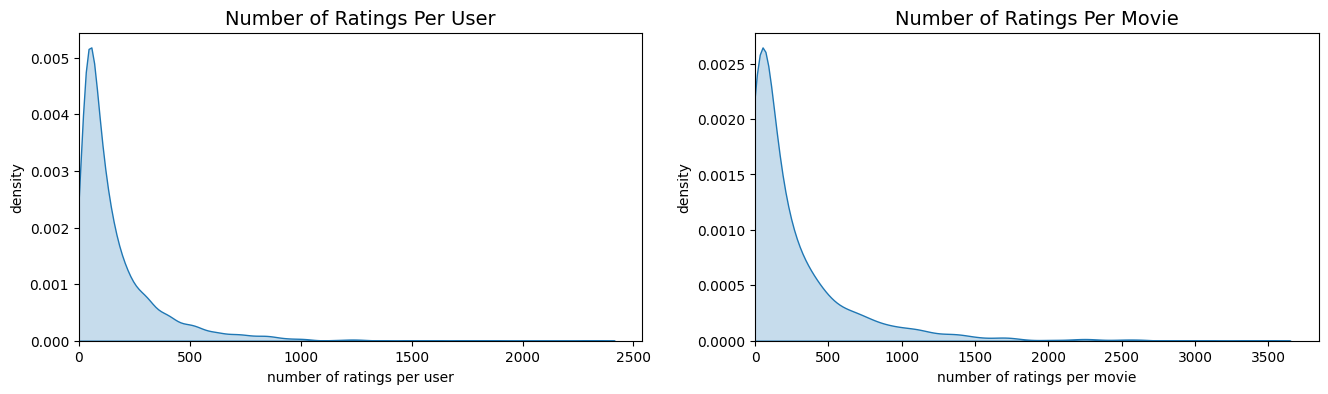

In [59]:
plt.figure(figsize=(16,4))
plt.subplot(1,2,1)
sns.kdeplot(n_ratings_per_user, shade=True)
plt.xlim(0)
plt.title("Number of Ratings Per User", fontsize=14)
plt.xlabel("number of ratings per user")
plt.ylabel("density")
plt.subplot(1,2,2)
sns.kdeplot(n_ratings_per_movie, shade=True)
plt.xlim(0)
plt.title("Number of Ratings Per Movie", fontsize=14)
plt.xlabel("number of ratings per movie")
plt.ylabel("density")
plt.show()

In [60]:
from sklearn.neighbors import NearestNeighbors

def find_similar_movies(movie_id, X, movie_mapper, movie_inv_mapper, k, metric='cosine'):
    """
    Finds k-nearest neighbours for a given movie id.

    Args:
        movie_id: id of the movie of interest
        X: user-item utility matrix
        k: number of similar movies to retrieve
        metric: distance metric for kNN calculations

    Output: returns list of k similar movie ID's
    """
    X = X.T
    neighbour_ids = []

    movie_ind = movie_mapper[movie_id]
    movie_vec = X[movie_ind]
    if isinstance(movie_vec, (np.ndarray)):
        movie_vec = movie_vec.reshape(1,-1)
    # use k+1 since kNN output includes the movieId of interest
    kNN = NearestNeighbors(n_neighbors=k+1, algorithm="brute", metric=metric)
    kNN.fit(X)
    neighbour = kNN.kneighbors(movie_vec, return_distance=False)
    for i in range(0,k):
        n = neighbour.item(i)
        neighbour_ids.append(movie_inv_mapper[n])
    neighbour_ids.pop(0)
    return neighbour_ids

In [61]:
similar_movies = find_similar_movies(1, X, movie_mapper, movie_inv_mapper, k=10)
similar_movies

[3114, 1265, 588, 2355, 1270, 34, 1196, 1580, 356]

In [62]:
movie_titles = dict(zip(df1['MovieID'], df1['Title']))

movie_id = 1

similar_movies = find_similar_movies(movie_id, X, movie_mapper, movie_inv_mapper, metric='cosine', k=10)
movie_title = movie_titles[movie_id]

print(f"Because you watched {movie_title}:")
for i in similar_movies:
    print(movie_titles[i])

Because you watched Toy Story (1995):
Toy Story 2 (1999)
Groundhog Day (1993)
Aladdin (1992)
Bug's Life, A (1998)
Back to the Future (1985)
Babe (1995)
Star Wars: Episode V - The Empire Strikes Back (1980)
Men in Black (1997)
Forrest Gump (1994)


In [63]:
movie_id = 1

similar_movies = find_similar_movies(movie_id, X, movie_mapper, movie_inv_mapper, metric='euclidean', k=10)
movie_title = movie_titles[movie_id]

print(f"Because you watched {movie_title}:")
for i in similar_movies:
    print(movie_titles[i])

Because you watched Toy Story (1995):
Aladdin (1992)
Toy Story 2 (1999)
Lion King, The (1994)
Bug's Life, A (1998)
Beauty and the Beast (1991)
Wayne's World (1992)
Pleasantville (1998)
Babe (1995)
Mask, The (1994)


In [64]:
n_movies = df1['MovieID'].nunique()
print(f"There are {n_movies} unique movies in our movies dataset.")

There are 3883 unique movies in our movies dataset.


In [65]:
genres = set(g for G in df1['Genres'] for g in G)

for g in genres:
    df1[g] = df1.Genres.transform(lambda x: int(g in x))

movie_genres = df1.drop(columns=['MovieID', 'Title','Genres'])

In [66]:
movie_genres.head()


,Comedy,Thriller,Animation,Musical,Mystery,Action,Adventure,Documentary,Sci-Fi,Romance,War,Drama,Horror,Film-Noir,Children's,Western,Fantasy,Crime
0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0
2,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [67]:
from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(movie_genres, movie_genres)
print(f"Dimensions of our genres cosine similarity matrix: {cosine_sim.shape}")

Dimensions of our genres cosine similarity matrix: (3883, 3883)


Text(120.72222222222221, 0.5, 'User Index')

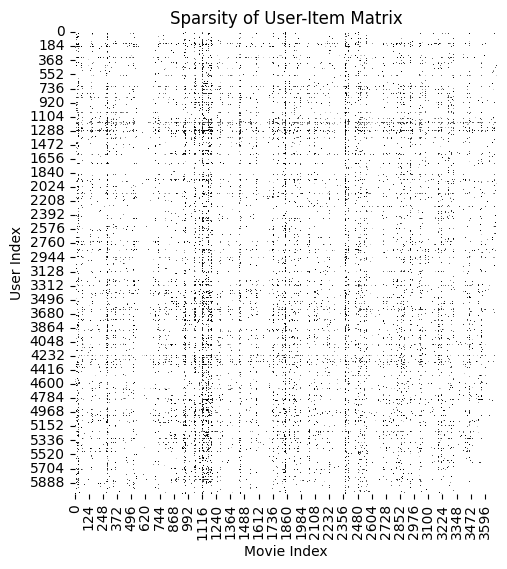

In [109]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.heatmap(X.toarray(), cmap='binary', cbar=False)
plt.title("Sparsity of User-Item Matrix")
plt.xlabel("Movie Index")
plt.ylabel("User Index")

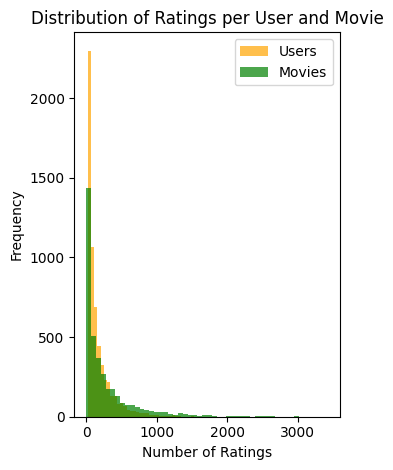

In [110]:
plt.subplot(1, 2, 2)
plt.hist(n_ratings_per_user, bins=50, color='orange', alpha=0.7, label="Users")
plt.hist(n_ratings_per_movie, bins=50, color='green', alpha=0.7, label="Movies")
plt.title("Distribution of Ratings per User and Movie")
plt.xlabel("Number of Ratings")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

In [68]:
import difflib

def movie_finder(title, all_titles):
    closest_match = difflib.get_close_matches(title, all_titles, n=1, cutoff=0.6)
    if closest_match:
        return closest_match[0]
    else:
        return None


In [69]:
all_titles = df1['Title'].tolist()

title = movie_finder('Shawshank Redemption', all_titles)
title

'Shawshank Redemption, The (1994)'

In [70]:
movie_idx = dict(zip(df1['Title'], list(df1.index)))
idx = movie_idx[title]
print(f"Movie index for Toy Story 2: {idx}")

Movie index for Toy Story 2: 315


In [71]:
n_recommendations=10
sim_scores = list(enumerate(cosine_sim[idx]))
sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
sim_scores = sim_scores[1:(n_recommendations+1)]
similar_movies = [i[0] for i in sim_scores]

In [72]:
print(f"Because you watched {title}:")
df1['Title'].iloc[similar_movies]

Because you watched Shawshank Redemption, The (1994):


25                                       Othello (1995)
26                                  Now and Then (1995)
29    Shanghai Triad (Yao a yao yao dao waipo qiao) ...
30                               Dangerous Minds (1995)
35                              Dead Man Walking (1995)
39                      Cry, the Beloved Country (1995)
42                                   Restoration (1995)
52                                      Lamerica (1994)
54                                       Georgia (1995)
56                         Home for the Holidays (1995)
Name: Title, dtype: object

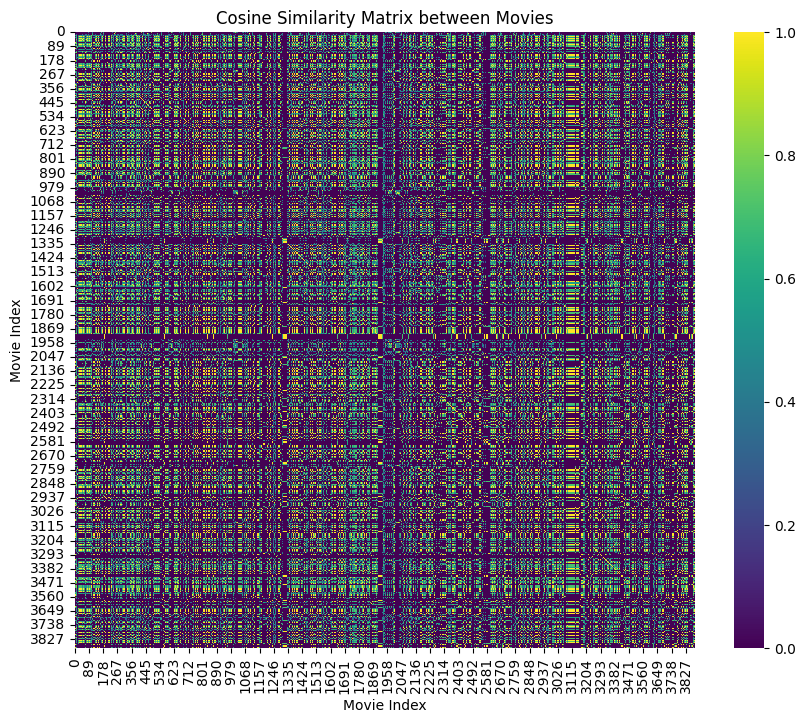

In [111]:
# Movie Similarity Visualization
plt.figure(figsize=(10, 8))
sns.heatmap(cosine_sim, cmap='viridis')
plt.title("Cosine Similarity Matrix between Movies")
plt.xlabel("Movie Index")
plt.ylabel("Movie Index")
plt.show()


In [73]:
def get_content_based_recommendations(title_string, n_recommendations=10):
    title = movie_finder(title_string, all_titles)
    idx = movie_idx[title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:(n_recommendations+1)]
    similar_movies = [i[0] for i in sim_scores]
    print(f"Because you watched {title}:")
    print(df1['Title'].iloc[similar_movies])

In [74]:
get_content_based_recommendations('Shawshank Redemptionn', 5)


Because you watched Shawshank Redemption, The (1994):
25                                       Othello (1995)
26                                  Now and Then (1995)
29    Shanghai Triad (Yao a yao yao dao waipo qiao) ...
30                               Dangerous Minds (1995)
35                              Dead Man Walking (1995)
Name: Title, dtype: object


In [75]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=20, n_iter=10)
Q = svd.fit_transform(X.T)
Q.shape

(3706, 20)

In [76]:
movie_id = 25
similar_movies = find_similar_movies(movie_id, Q.T, movie_mapper, movie_inv_mapper, metric='cosine', k=10)
movie_title = movie_titles[movie_id]

print(f"Because you watched {movie_title}:")
for i in similar_movies:
    print(movie_titles[i])

Because you watched Leaving Las Vegas (1995):
Dead Man Walking (1995)
Sling Blade (1996)
Shine (1996)
Crying Game, The (1992)
What's Eating Gilbert Grape (1993)
Insider, The (1999)
Some Folks Call It a Sling Blade (1993)
Malcolm X (1992)
Thelma & Louise (1991)


In [98]:
def user_based_recommendations(user_id, X, movie_inv_mapper, k=10, metric='cosine'):
    user_ind = user_mapper[user_id]
    user_vec = X[user_ind]
    if isinstance(user_vec, (np.ndarray)):
        user_vec = user_vec.reshape(1,-1)
    kNN = NearestNeighbors(n_neighbors=k, algorithm="brute", metric=metric)
    kNN.fit(X)
    neighbor_indices = kNN.kneighbors(user_vec, return_distance=False)
    user_recommendations = []
    for i in neighbor_indices[0]:
        movie_id = movie_inv_mapper[i]
        user_recommendations.extend(find_similar_movies(movie_id, X, movie_mapper, movie_inv_mapper, k=5, metric='cosine'))
    return user_recommendations


In [97]:
def hybrid_recommendations(title_string, n_recommendations=10):
    title = movie_finder(title_string, all_titles)
    idx = movie_idx[title]
    # Collaborative filtering
    sim_scores_collab = list(enumerate(cosine_sim[idx]))
    sim_scores_collab = sorted(sim_scores_collab, key=lambda x: x[1], reverse=True)
    sim_scores_collab = sim_scores_collab[1:(n_recommendations+1)]
    similar_movies_collab = [i[0] for i in sim_scores_collab]

    # Content-based filtering
    sim_scores_content = list(enumerate(cosine_sim[idx]))
    sim_scores_content = sorted(sim_scores_content, key=lambda x: x[1], reverse=True)
    sim_scores_content = sim_scores_content[1:(n_recommendations+1)]
    similar_movies_content = [i[0] for i in sim_scores_content]

    print(f"Because you watched {title}:")
    print("Collaborative filtering recommendations:")
    print(df1['Title'].iloc[similar_movies_collab])
    print("\nContent-based filtering recommendations:")
    print(df1['Title'].iloc[similar_movies_content])

hybrid_recommendations('Toy Story 2', 5)

Because you watched Toy Story 2 (1999):
Collaborative filtering recommendations:
1050        Aladdin and the King of Thieves (1996)
2072                      American Tail, An (1986)
2073    American Tail: Fievel Goes West, An (1991)
2285                     Rugrats Movie, The (1998)
2286                          Bug's Life, A (1998)
Name: Title, dtype: object

Content-based filtering recommendations:
1050        Aladdin and the King of Thieves (1996)
2072                      American Tail, An (1986)
2073    American Tail: Fievel Goes West, An (1991)
2285                     Rugrats Movie, The (1998)
2286                          Bug's Life, A (1998)
Name: Title, dtype: object


In [103]:
from datetime import datetime

def get_time_of_day():
    current_time = datetime.now()
    hour = current_time.hour
    if 6 <= hour < 12:
        return 'morning'
    elif 12 <= hour < 18:
        return 'afternoon'
    elif 18 <= hour < 22:
        return 'evening'
    else:
        return 'night'

def recommend_temporal(user_id, movies_df):
    # Get the current time of day
    time_of_day = get_time_of_day()

    # Define temporal preferences based on time of day
    temporal_preferences = {
        'morning': ['Drama', 'Romance', 'Comedy'],
        'afternoon': ['Action', 'Adventure', 'Thriller'],
        'evening': ['Drama', 'Comedy', 'Romance'],
        'night': ['Horror', 'Thriller', 'Mystery']
    }

    # Get genre preferences for the given time of day
    preferred_genres = temporal_preferences.get(time_of_day, [])

    # Filter movies based on preferred genres
    recommended_movies = df1[df1['Genres'].apply(lambda x: any(genre in x for genre in preferred_genres))]

    # Return a sample of recommended movies
    return recommended_movies.sample(n=10)

In [104]:
# Example usage of recommend_temporal
user_id = 1
recommended_temporal_movies = recommend_temporal(user_id, df1)
print(f"Temporal Recommendations for the current time of day:")
print(recommended_temporal_movies[['Title', 'Genres']])

Temporal Recommendations for the current time of day:
                                  Title                      Genres
2922            Live and Let Die (1973)                    [Action]
1024          Lawnmower Man, The (1992)  [Action, Sci-Fi, Thriller]
2499              Mod Squad, The (1999)             [Action, Crime]
2008  Journey of Natty Gann, The (1985)     [Adventure, Children's]
1792                   Junk Mail (1997)          [Comedy, Thriller]
1558                       Steel (1997)                    [Action]
1362    Adrenalin: Fear the Rush (1996)            [Action, Sci-Fi]
1041           Shadow Conspiracy (1997)                  [Thriller]
346                  Client, The (1994)  [Drama, Mystery, Thriller]
2664                       Vibes (1988)         [Adventure, Comedy]


In [78]:
from google.colab import drive
drive.mount('/content/drive')

KeyboardInterrupt: 